## Market

Market data describes the commercial side of the electricity system.

These datasets are useful for understanding how electricity is traded and how
prices and commercial positions are formed.

### Typical units

- Price: `EUR/MWh`
- Power/exchange: `MW`

### Typical applications

- Electricity price forecasting
- Market analysis
- Market coupling analysis
- Bidding strategies
- Cross-border trading analysis

---

# Config

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

In [32]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)

# Mappings
---

In [74]:
process_types = {
    'A01': 'Day ahead',
    'A02': 'Intra day incremental',
    'A16': 'Realised',
    'A18': 'Intraday total',
    'A31': 'Week ahead',
    'A32': 'Month ahead',
    'A33': 'Year ahead',
    'A39': 'Synchronisation process',
    'A40': 'Intraday process',
    'A46': 'Replacement reserve',
    'A47': 'Manual frequency restoration reserve',
    'A51': 'Automatic frequency restoration reserve',
    'A52': 'Frequency containment reserve',
    'A56': 'Frequency restoration reserve',
    'A60': 'Scheduled activation mFRR',
    'A61': 'Direct activation mFRR',
    'A67': 'Central Selection aFRR',
    'A68': 'Local Selection aFRR'
}

# EDA
---

###################################################################################
# .query_day_ahead_prices
(country_code, start=start, end=end) -> pd.Series

* Day-ahead market clearing price (€/MWh).

In [80]:
day_ahead_prices = entsoe_client.query_day_ahead_prices(
    country_code=country_code,
    start=last_month,
    end=day_after_tomorrow)

In [81]:
day_ahead_prices.info()

<class 'pandas.Series'>
DatetimeIndex: 3168 entries, 2026-07-26 00:00:00+02:00 to 2026-08-27 23:45:00+02:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
3168 non-null   float64
dtypes: float64(1)
memory usage: 49.5 KB


In [35]:
day_ahead_prices.head()

2026-07-26 00:00:00+02:00    139.35
2026-07-26 00:15:00+02:00    135.47
2026-07-26 00:30:00+02:00    131.06
2026-07-26 00:45:00+02:00    129.48
2026-07-26 01:00:00+02:00    132.64
dtype: float64

In [36]:
day_ahead_prices.tail()

2026-08-27 22:45:00+02:00    176.46
2026-08-27 23:00:00+02:00    174.88
2026-08-27 23:15:00+02:00    170.61
2026-08-27 23:30:00+02:00    166.49
2026-08-27 23:45:00+02:00    155.41
dtype: float64

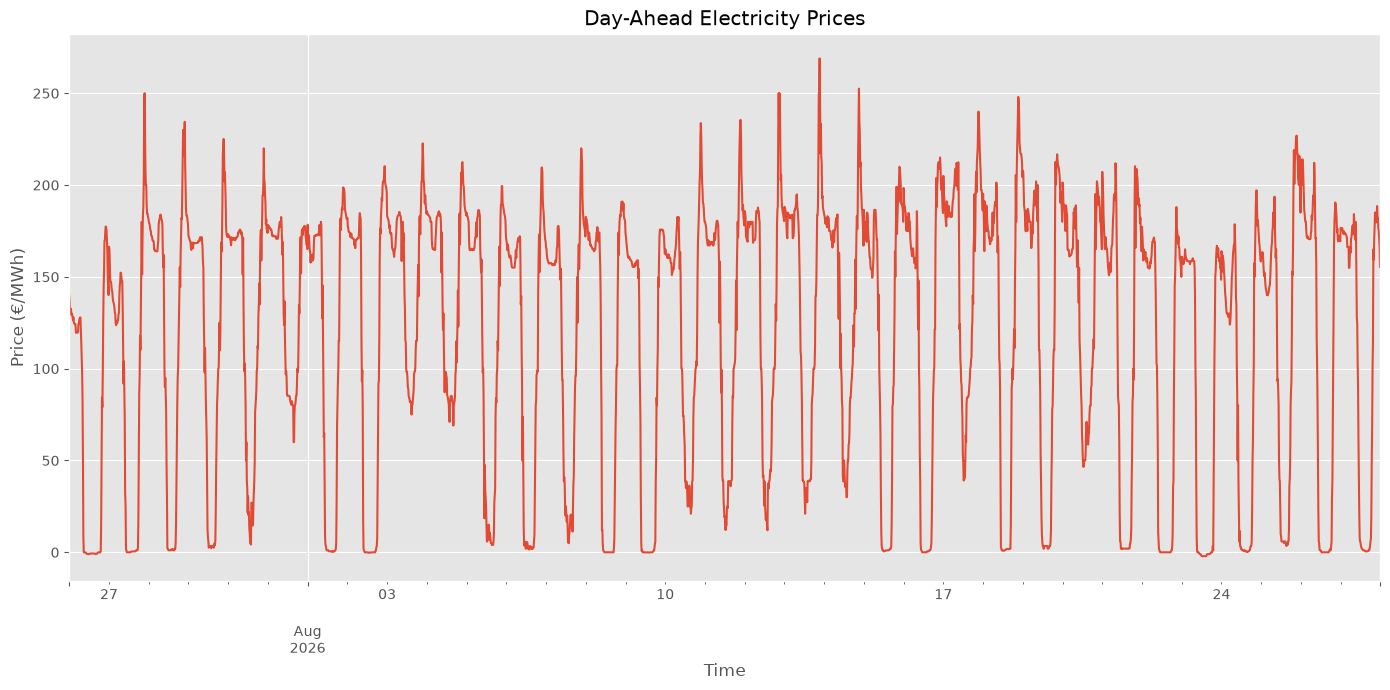

In [70]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.plot(ax=ax)

ax.set_title("Day-Ahead Electricity Prices")
ax.set_xlabel("Time")
ax.set_ylabel("Price (€/MWh)")

fig.tight_layout()
plt.show()

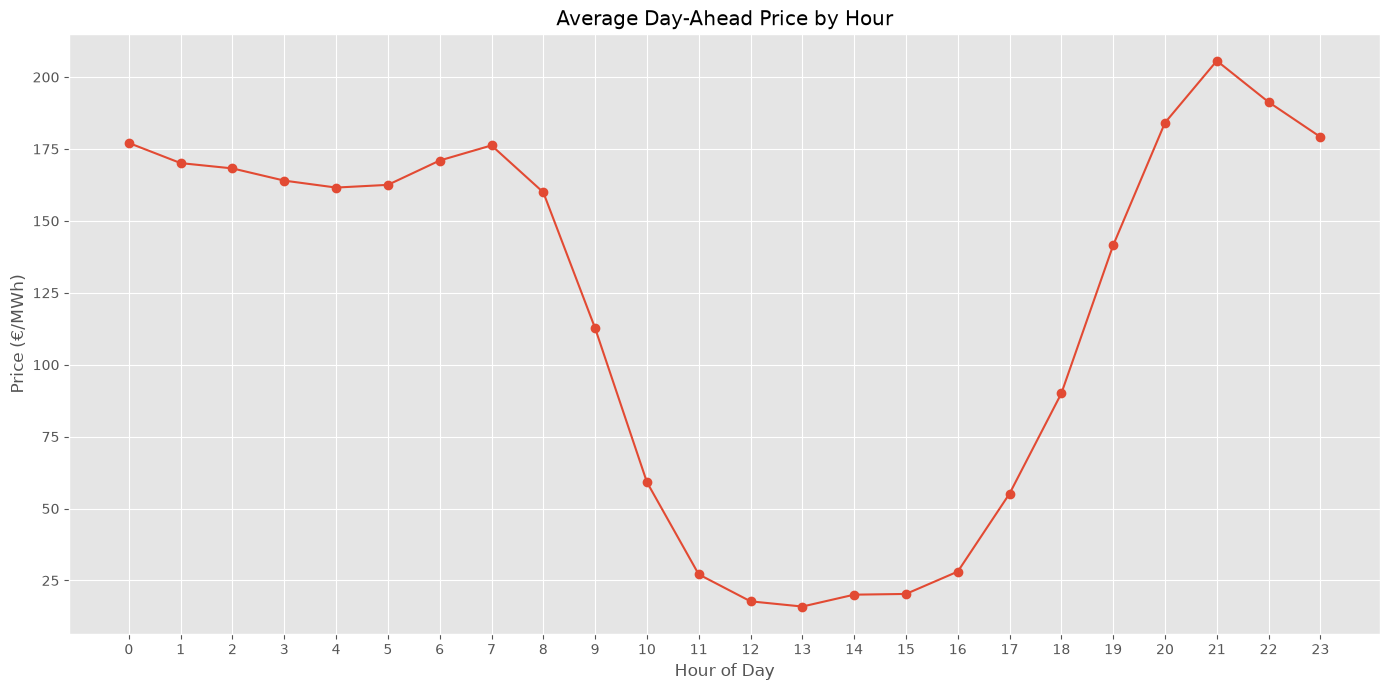

In [69]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.groupby(day_ahead_prices.index.hour).mean().plot(
    ax=ax,
    marker="o"
)

ax.set_title("Average Day-Ahead Price by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Price (€/MWh)")
ax.set_xticks(range(24))

fig.tight_layout()
plt.show()

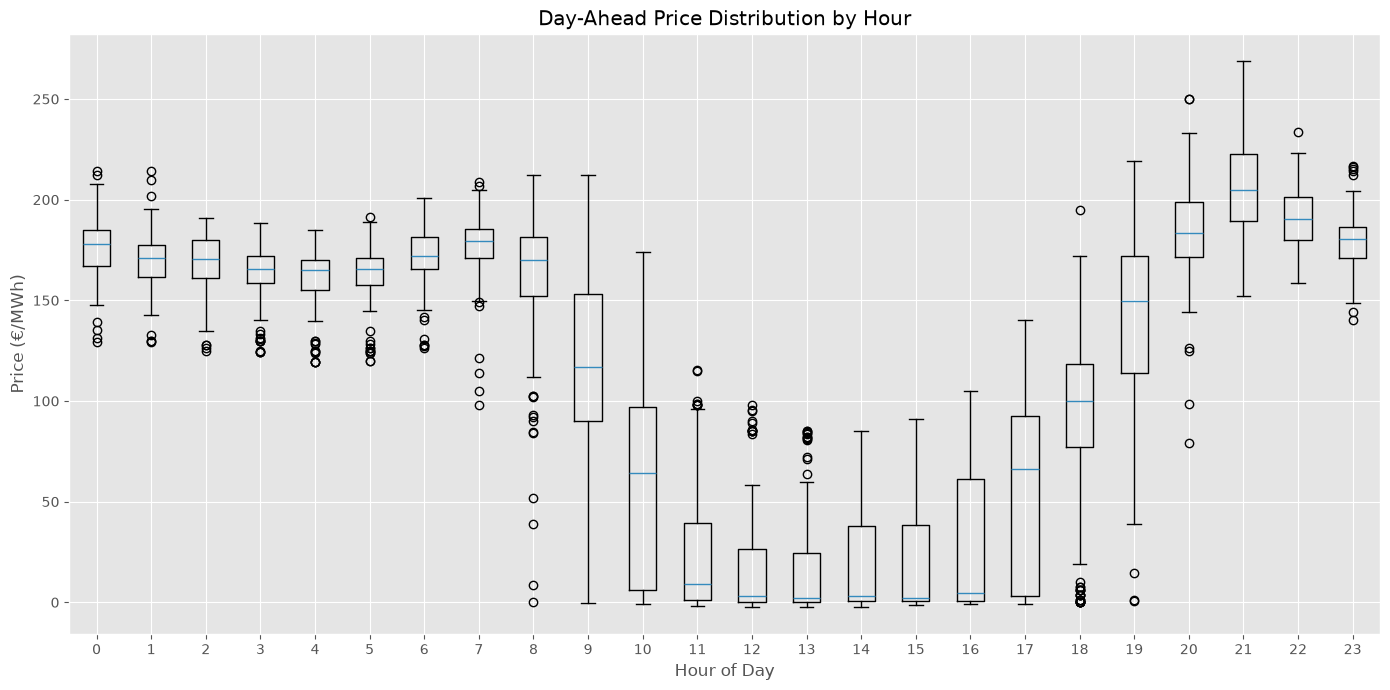

In [68]:
prices_by_hour = [
    day_ahead_prices[day_ahead_prices.index.hour == hour].values
    for hour in range(24)
]

fig, ax = plt.subplots(figsize=(14, 7))

ax.boxplot(prices_by_hour)

ax.set_title("Day-Ahead Price Distribution by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Price (€/MWh)")
ax.set_xticks(range(1, 25), range(24))

fig.tight_layout()
plt.show()

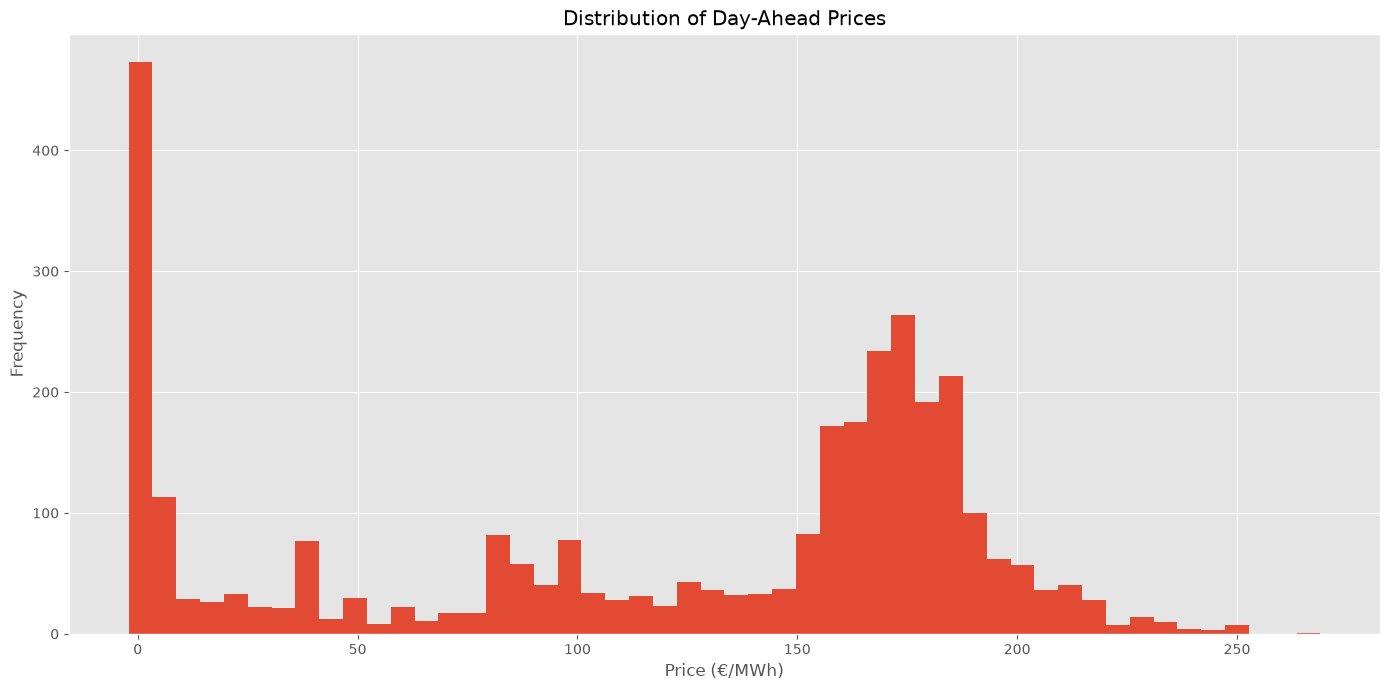

In [71]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.plot.hist(
    bins=50,
    ax=ax
)

ax.set_title("Distribution of Day-Ahead Prices")
ax.set_xlabel("Price (€/MWh)")
ax.set_ylabel("Frequency")

fig.tight_layout()
plt.show()

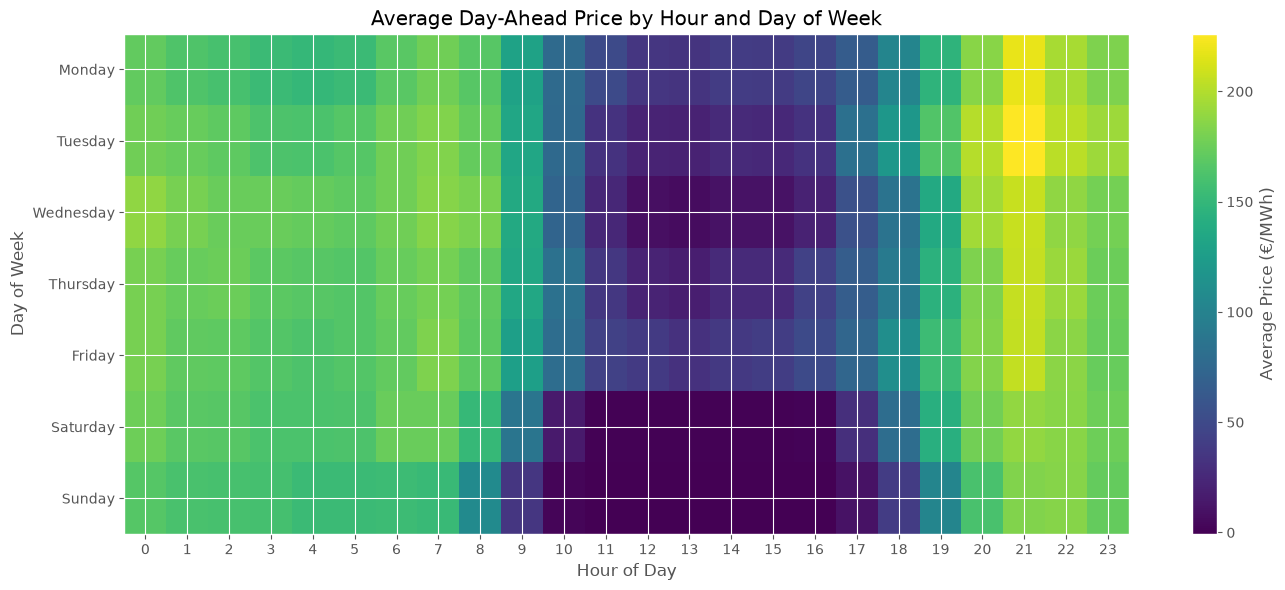

In [72]:
prices = day_ahead_prices.copy()
prices.index = pd.to_datetime(prices.index)

# Average price for each hour and day of week
heatmap_data = (
    prices
    .groupby([
        prices.index.day_name(),
        prices.index.hour
    ])
    .mean()
    .unstack()
)

# Put days in the correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heatmap_data = heatmap_data.reindex(day_order)


fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Axis labels
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Average Day-Ahead Price by Hour and Day of Week")

# Ticks
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(7))
ax.set_yticklabels(day_order)

# Colorbar
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Average Price (€/MWh)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_aggregated_bids
(country_code, start=start, end=end, process_type) -> pd.Series

* Aggregated market bids (MW).

In [ ]:
# ### processType allowed values: A51, A46, A47, A60, A61, A67, A68' ###

# for process_type in process_types:
#     try:
#         df = entsoe_client.query_aggregated_bids(
#                 country_code=country_code,
#                 start=last_week,
#                 end=tomorrow,
#                 process_type=process_type
#         )
#         print(process_type, df.shape)
#     except Exception as e:
#         print(process_type, repr(e))

In [ ]:
allowed_process_types_agg_bids = {
    # 'A46': 'Replacement reserve',
    'A47': 'Manual frequency restoration reserve',
    'A51': 'Automatic frequency restoration reserve',
    # 'A60': 'Scheduled activation mFRR',
    # 'A61': 'Direct activation mFRR',
    'A67': 'Central Selection aFRR',
    # 'A68': 'Local Selection aFRR'
}

In [ ]:
aggregated_bids_aFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A51")

In [56]:
aggregated_bids_aFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 725 entries, 2026-08-19 00:00:00+02:00 to 2026-08-26 13:00:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  0 non-null      object
 1   (Down, 1, Offered)    653 non-null    object
 2   (Up, 2, Activated)    0 non-null      object
 3   (Up, 2, Offered)      608 non-null    object
dtypes: object(4)
memory usage: 28.3+ KB


In [57]:
aggregated_bids_aFRR.head()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-08-19 00:00:00+02:00       NaN  1135.0       NaN  1165.0
2026-08-19 00:15:00+02:00       NaN  1151.0       NaN  1166.0
2026-08-19 00:30:00+02:00       NaN  1160.0       NaN  1148.0
2026-08-19 00:45:00+02:00       NaN  1164.0       NaN  1001.0
2026-08-19 01:00:00+02:00       NaN  1062.0       NaN  1048.0

In [58]:
aggregated_bids_aFRR.tail()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-08-26 12:00:00+02:00       NaN     NaN       NaN     NaN
2026-08-26 12:15:00+02:00       NaN     NaN       NaN     NaN
2026-08-26 12:30:00+02:00       NaN     NaN       NaN     NaN
2026-08-26 12:45:00+02:00       NaN     NaN       NaN     NaN
2026-08-26 13:00:00+02:00       NaN     NaN       NaN     NaN

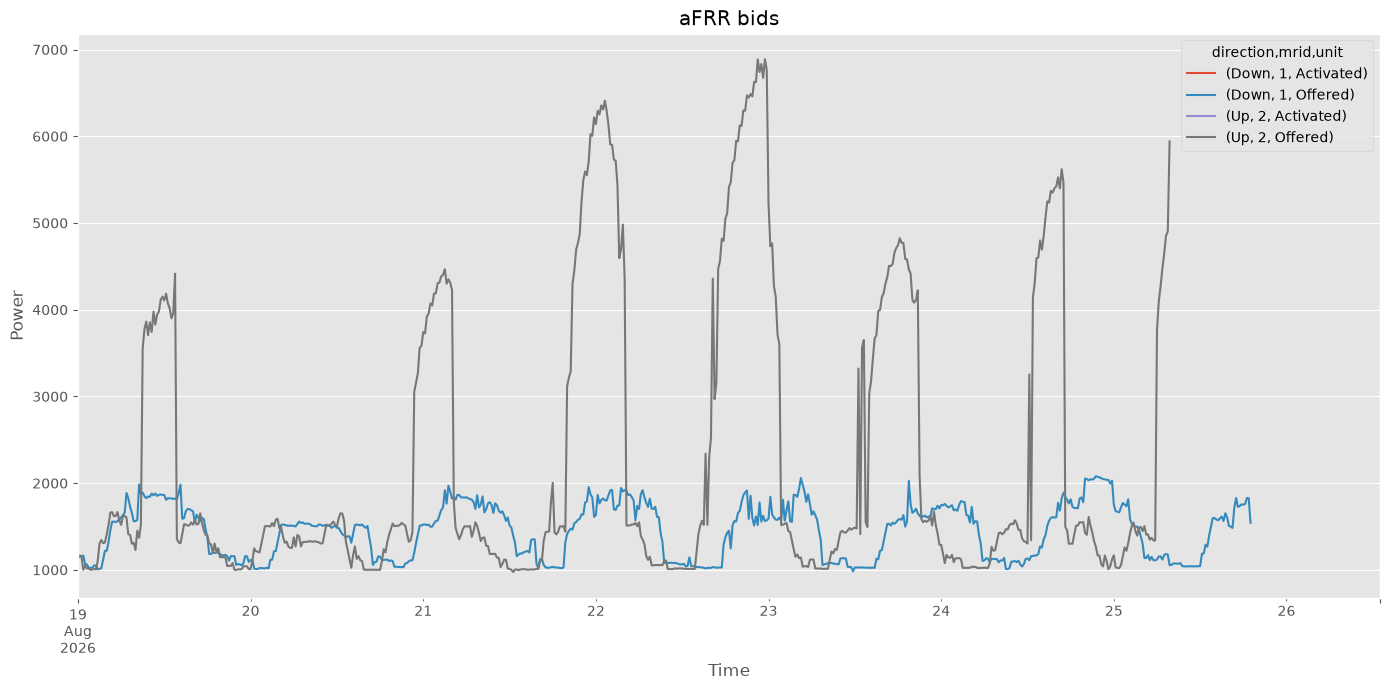

In [64]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_aFRR.plot(ax=ax)

ax.set_title("aFRR bids")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

In [60]:
aggregated_bids_mFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A47")

In [61]:
aggregated_bids_mFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 726 entries, 2026-08-19 00:00:00+02:00 to 2026-08-26 13:15:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  0 non-null      object
 1   (Down, 1, Offered)    726 non-null    object
 2   (Up, 2, Activated)    0 non-null      object
 3   (Up, 2, Offered)      723 non-null    object
dtypes: object(4)
memory usage: 28.4+ KB


In [62]:
aggregated_bids_mFRR.head()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-08-19 00:00:00+02:00       NaN  7249.0       NaN  6116.0
2026-08-19 00:15:00+02:00       NaN  7837.0       NaN  6498.0
2026-08-19 00:30:00+02:00       NaN  7608.0       NaN  6583.0
2026-08-19 00:45:00+02:00       NaN  7643.0       NaN  6657.0
2026-08-19 01:00:00+02:00       NaN  7591.0       NaN  6694.0

In [63]:
aggregated_bids_mFRR.tail()

direction                      Down                 Up        
mrid                              1                  2        
unit                      Activated  Offered Activated Offered
2026-08-26 12:15:00+02:00       NaN  10291.0       NaN  8027.0
2026-08-26 12:30:00+02:00       NaN  10783.0       NaN  8135.0
2026-08-26 12:45:00+02:00       NaN  10931.0       NaN     NaN
2026-08-26 13:00:00+02:00       NaN  11303.0       NaN     NaN
2026-08-26 13:15:00+02:00       NaN  11414.0       NaN     NaN

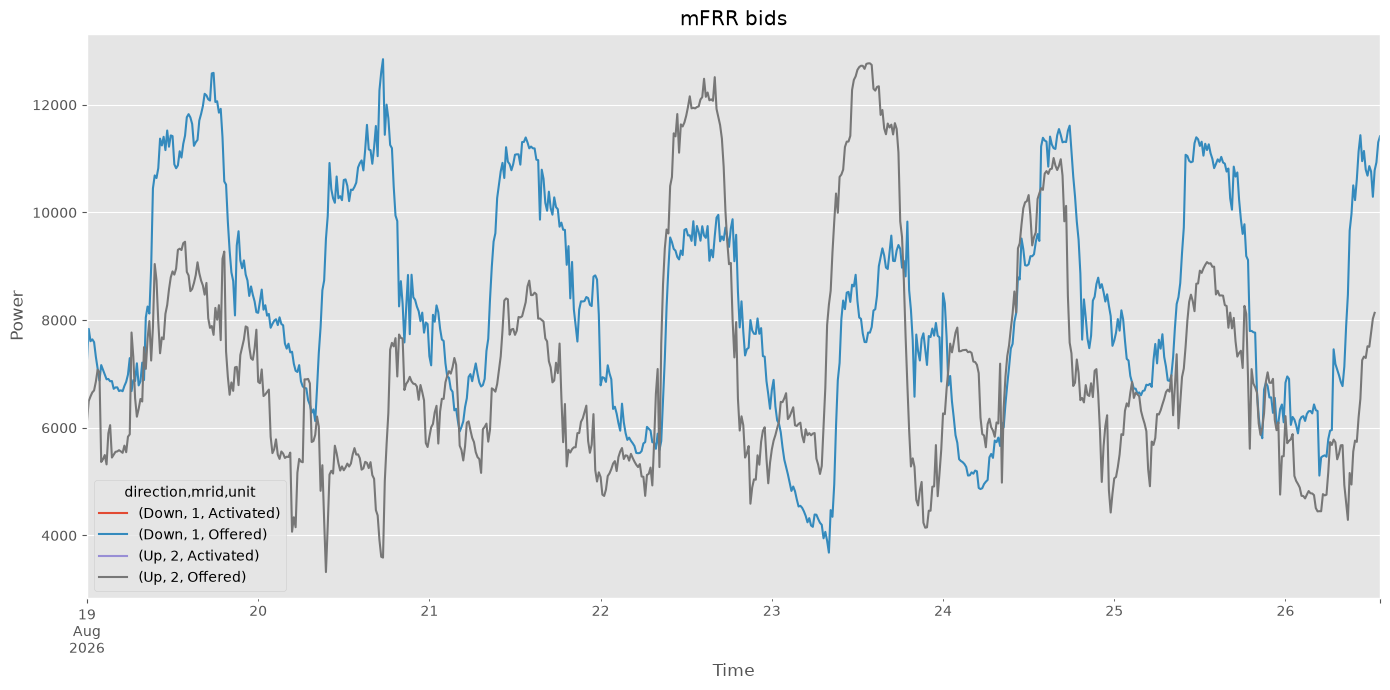

In [65]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_mFRR.plot(ax=ax)

ax.set_title("mFRR bids")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

In [103]:
aggregated_bids_central_selection_aFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A67")

In [106]:
aggregated_bids_central_selection_aFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 727 entries, 2026-08-19 00:00:00+02:00 to 2026-08-26 13:30:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  721 non-null    object
 1   (Down, 1, Offered)    721 non-null    object
 2   (Up, 2, Activated)    725 non-null    object
 3   (Up, 2, Offered)      725 non-null    object
dtypes: object(4)
memory usage: 28.4+ KB


In [107]:
aggregated_bids_central_selection_aFRR.head()

direction                      Down                 Up         
mrid                              1                  2         
unit                      Activated  Offered Activated  Offered
2026-08-19 00:00:00+02:00    42.517  1135.07       0.0   1165.0
2026-08-19 00:15:00+02:00   169.994  1151.04    1.4806   1165.0
2026-08-19 00:30:00+02:00   170.359  1160.02       0.0  1165.92
2026-08-19 00:45:00+02:00   257.546  1163.55       0.0  1147.35
2026-08-19 01:00:00+02:00    0.3632   1062.0   200.343   1001.0

In [108]:
aggregated_bids_central_selection_aFRR.tail()

direction                      Down                Up         
mrid                              1                 2         
unit                      Activated Offered Activated  Offered
2026-08-26 12:30:00+02:00       NaN     NaN    384.85   1388.0
2026-08-26 12:45:00+02:00       NaN     NaN   22.0621  1387.99
2026-08-26 13:00:00+02:00       NaN     NaN       0.0   1386.0
2026-08-26 13:15:00+02:00       NaN     NaN       NaN      NaN
2026-08-26 13:30:00+02:00       NaN     NaN       NaN      NaN

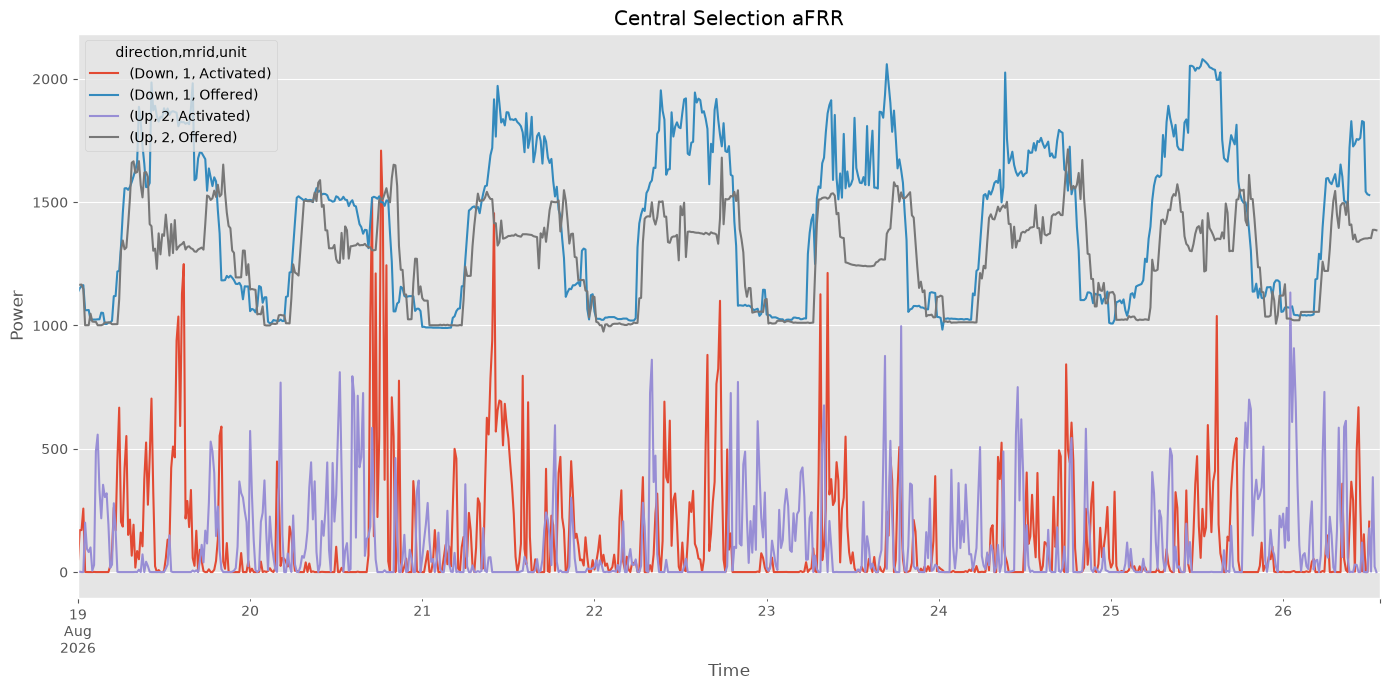

In [110]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_central_selection_aFRR.plot(ax=ax)

ax.set_title("Central Selection aFRR")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

###################################################################################
# .query_net_position
(country_code, start=start, end=end, dayahead=True) -> pd.Series

- as defined by CACM article 2(5): “the netted sum of electricity exports and imports for each market time unit for a bidding zone” expressed in MW
- the day-ahead implicit net position consists of the sum of all commercial exchanges across all bidding zone borders from implicit day-ahead allocations.
- the total implicit net position consists of the sum of all commercial exchanges across all bidding zone borders from implicit day-ahead allocations as well as all implicit intraday allocations (including continuous allocations), as a single publication of values for the entire day.
- he explicit allocations, TSO-TSO schedules (due to redispatch and countertrade) and balancing schedules are not included.
- primary owner of the data: net positions are calculated by Market Operator (PXs)
- data provider: net positions (TCA, TSO or task delegated to third party (E.g. Market Operator,)

Source: ENTSOE MoP V3R5

* This is a market-scheduled position, not necessarily the physical flow actually observed on the transmission network.

In [121]:
net_positions = entsoe_client.query_net_position(
    country_code=country_code,
    start=last_week,
    end=day_after_tomorrow,
    dayahead=True)

In [122]:
net_positions.info()

<class 'pandas.Series'>
DatetimeIndex: 864 entries, 2026-08-19 00:00:00+02:00 to 2026-08-27 23:45:00+02:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [123]:
net_positions.head()

2026-08-19 00:00:00+02:00   -805.3
2026-08-19 00:15:00+02:00   -557.1
2026-08-19 00:30:00+02:00   -429.6
2026-08-19 00:45:00+02:00   -199.1
2026-08-19 01:00:00+02:00   -171.9
dtype: float64

In [124]:
net_positions.tail()

2026-08-27 22:45:00+02:00    3368.2
2026-08-27 23:00:00+02:00    3197.4
2026-08-27 23:15:00+02:00    2630.6
2026-08-27 23:30:00+02:00    2776.4
2026-08-27 23:45:00+02:00    2438.3
dtype: float64

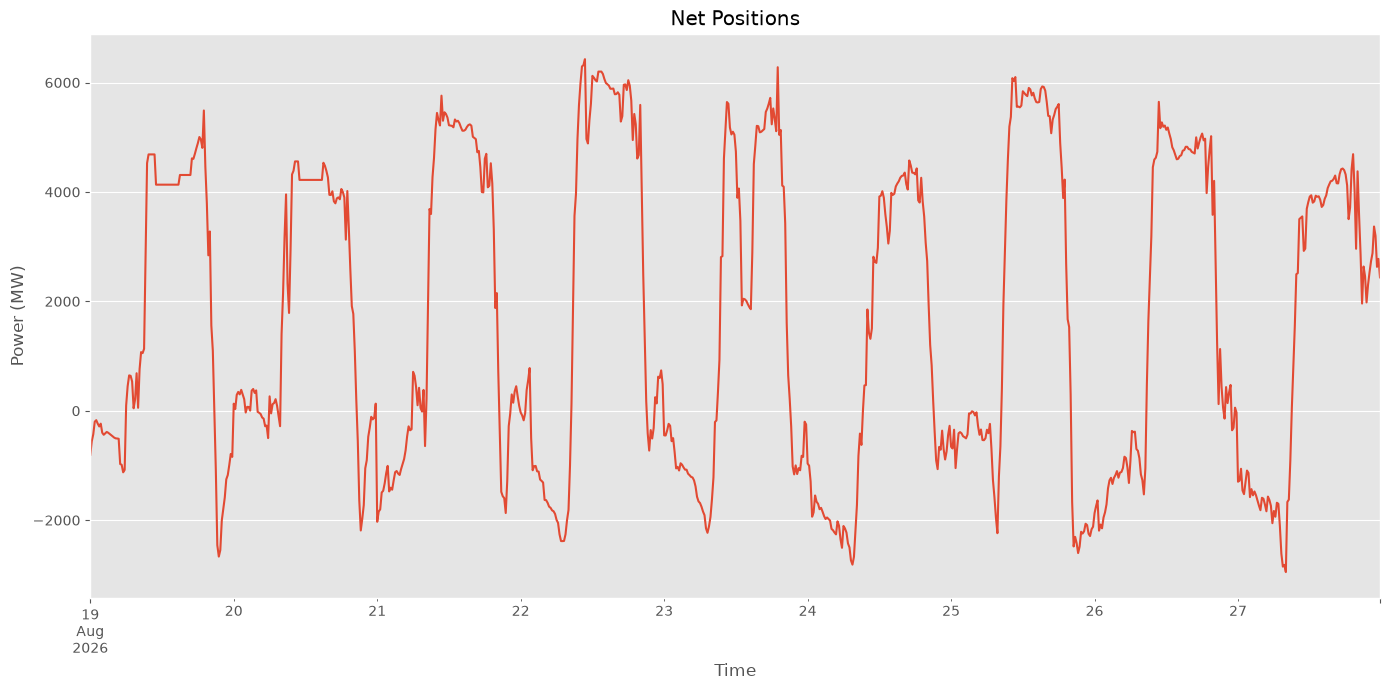

In [128]:
fig, ax = plt.subplots(figsize=(14, 7))

net_positions.plot(ax=ax)

ax.set_title("Net Positions")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_scheduled_exchanges
(country_code_from, country_code_to, start=start, end=end, dayahead=False) -> pd.Series

* Scheduled commercial cross-border electricity exchanges.

In [139]:
scheduled_exchanges = entsoe_client.query_scheduled_exchanges(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week,
    end=day_after_tomorrow,
    dayahead=False)

In [140]:
scheduled_exchanges.info()

<class 'pandas.Series'>
DatetimeIndex: 864 entries, 2026-08-19 00:00:00+02:00 to 2026-08-27 23:45:00+02:00
Freq: 15min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [141]:
scheduled_exchanges.head()

2026-08-19 00:00:00+02:00    775.1
2026-08-19 00:15:00+02:00    212.1
2026-08-19 00:30:00+02:00    111.9
2026-08-19 00:45:00+02:00    105.5
2026-08-19 01:00:00+02:00    333.6
Freq: 15min, dtype: float64

In [142]:
scheduled_exchanges.tail()

2026-08-27 22:45:00+02:00    2099.2
2026-08-27 23:00:00+02:00    1562.1
2026-08-27 23:15:00+02:00     689.1
2026-08-27 23:30:00+02:00     826.3
2026-08-27 23:45:00+02:00     264.9
Freq: 15min, dtype: float64

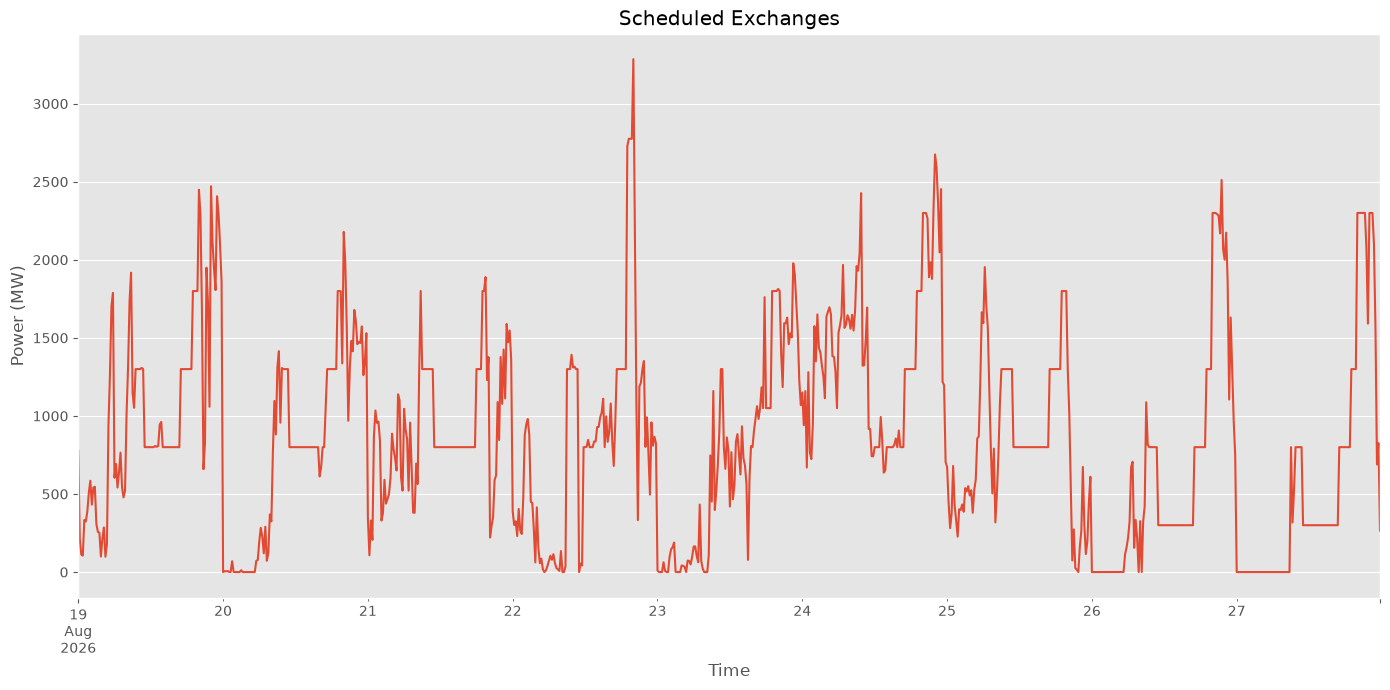

In [144]:
fig, ax = plt.subplots(figsize=(14, 7))

scheduled_exchanges.plot(ax=ax)

ax.set_title("Scheduled Exchanges")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

fig.tight_layout()
plt.show()